#load the dataset

In [ ]:
import pandas as pd
rating = pd.read_csv(
    "data/ratings.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["userId", "movieId", "rating", "timestamp"]
)

movies = pd.read_csv(
    "data/movies.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["movieId", "title", "genres"]
)

users = pd.read_csv(
    "data/users.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["userId", "gender", "age", "occupation", "zipCode"]
)

In [ ]:
rating.head()

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


#2.Data Cleaning Steps

**1..Clean rating data**





In [ ]:
rating.shape

(1000209, 4)

In [ ]:
rating.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [ ]:
rating.duplicated().sum()

np.int64(0)

In [ ]:
rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   userId     1000209 non-null  int64
 1   movieId    1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


..Check rating values

In [ ]:
print("Unique Ratings:")
print(sorted(rating["rating"].unique()))

print("\nMinimum Rating:", rating["rating"].min())
print("Maximum Rating:", rating["rating"].max())

Unique Ratings:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Minimum Rating: 1
Maximum Rating: 5


..Validate IDs

In [ ]:
print("Invalid User IDs:", (rating["userId"] <= 0).sum())
print("Invalid Movie IDs:", (rating["movieId"] <= 0).sum())

Invalid User IDs: 0
Invalid Movie IDs: 0


..validate ratings

In [ ]:
rating = rating.dropna()
rating = rating.drop_duplicates()

rating = rating[
    (rating["userId"] > 0) &
    (rating["movieId"] > 0) &
    (rating["rating"] >= 1) &
    (rating["rating"] <= 5)
]

rating = rating.reset_index(drop=True)

In [ ]:
print("Final Shape:", rating.shape)
rating.head()

Final Shape: (1000209, 4)


,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


..Save the cleaned ratings

In [ ]:
rating.to_csv(
    "ratings_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Data Cleaning

The MovieLens 1M ratings dataset was inspected for missing values,
duplicate records, invalid user/movie IDs, and ratings outside the
valid 1–5 range.

The `ratings` dataset contains four variables: `userId`, `movieId`,
`rating`, and `timestamp`. Missing values and duplicate records were
removed where necessary, and ratings were validated to ensure they
were within the expected 1–5 range.

After cleaning, the dataset was saved as `ratings_cleaned.csv` for
further exploratory analysis and collaborative filtering.


---



**2..Clean movies data**






In [ ]:
print("\nFirst 5 Rows:")
display(movies.head())


First 5 Rows:


,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
print("Dataset Shape:", movies.shape)




Dataset Shape: (3883, 3)


In [ ]:

print("\nDataset Info:")
movies.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  3883 non-null   int64 
 1   title    3883 non-null   object
 2   genres   3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB


In [ ]:
movies.isnull().sum()

,0
movieId,0
title,0
genres,0


In [ ]:
movies.duplicated().sum()

np.int64(0)

..Movies id duplicacy

In [ ]:
print("Duplicate Movie IDs:", movies["movieId"].duplicated().sum())

Duplicate Movie IDs: 0


..Validate movies id

In [ ]:
print("Invalid Movie IDs:", (movies["movieId"] <= 0).sum())

Invalid Movie IDs: 0


..Check empty titles

In [ ]:
print("Empty Titles:", (movies["title"].str.strip() == "").sum())

Empty Titles: 0


..Clean text columns

In [ ]:
movies["title"] = movies["title"].str.strip()
movies["genres"] = movies["genres"].str.strip()

..Check genres

In [ ]:
print("Number of unique genre combinations:", movies["genres"].nunique())

print("\nSample Genres:")
print(movies["genres"].unique()[:20])

Number of unique genre combinations: 301

Sample Genres:
["Animation|Children's|Comedy" "Adventure|Children's|Fantasy"
 'Comedy|Romance' 'Comedy|Drama' 'Comedy' 'Action|Crime|Thriller'
 "Adventure|Children's" 'Action' 'Action|Adventure|Thriller'
 'Comedy|Drama|Romance' 'Comedy|Horror' "Animation|Children's" 'Drama'
 'Action|Adventure|Romance' 'Drama|Thriller' 'Drama|Romance' 'Thriller'
 'Action|Comedy|Drama' 'Crime|Drama|Thriller' 'Drama|Sci-Fi']


..Verify data

In [ ]:
movies = movies.dropna(subset=["movieId", "title"])

movies["genres"] = movies["genres"].fillna("Unknown")

movies = movies.drop_duplicates()

movies = movies.drop_duplicates(
    subset="movieId",
    keep="first"
)

movies = movies[
    movies["movieId"] > 0
]

movies["title"] = movies["title"].str.strip()
movies["genres"] = movies["genres"].str.strip()

movies = movies.reset_index(drop=True)

..Save cleaned movie data

In [ ]:
movies.to_csv(
    "movies_cleaned.csv",
    index=False
)

print("Cleaned movie dataset saved successfully!")

Cleaned movie dataset saved successfully!


## Movie Data Cleaning

The MovieLens movie dataset contains three columns: `movieId`, `title`,
and `genres`. The dataset was inspected for missing values, duplicate
records, duplicate movie IDs, invalid movie IDs, and empty movie titles.

Missing movie titles were removed because they are required for displaying
recommendations, while missing genre values were replaced with `Unknown`.
Movie IDs were validated to ensure they were positive and unique. Leading
and trailing whitespace was also removed from text fields.

The cleaned movie dataset was saved as `movies_cleaned.csv` and will be
used later to map predicted movie IDs to movie titles and genres.


---



#3.Exploratory Data Analysis
..Loads the Cleanest dataset

In [ ]:
import pandas as pd

ratings = pd.read_csv("ratings_cleaned.csv")
movies = pd.read_csv("movies_cleaned.csv")

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

Ratings shape: (1000209, 4)
Movies shape: (3883, 3)


..Dataset Statistics

In [ ]:
num_users = ratings["userId"].nunique()
num_movies = ratings["movieId"].nunique()
num_ratings = len(ratings)

print("Number of Users:", num_users)
print("Number of Movies:", num_movies)
print("Number of Ratings:", num_ratings)

Number of Users: 6040
Number of Movies: 3706
Number of Ratings: 1000209


..Rating statistics

In [ ]:
ratings["rating"].describe()


,rating
count,1.000209e+06
mean,3.581564e+00
std,1.117102e+00
min,1.000000e+00
25%,3.000000e+00
50%,4.000000e+00
75%,4.000000e+00
max,5.000000e+00


In [ ]:
print("Average Rating:", round(ratings["rating"].mean(), 2))

Average Rating: 3.58


**i.Rating Distribution**

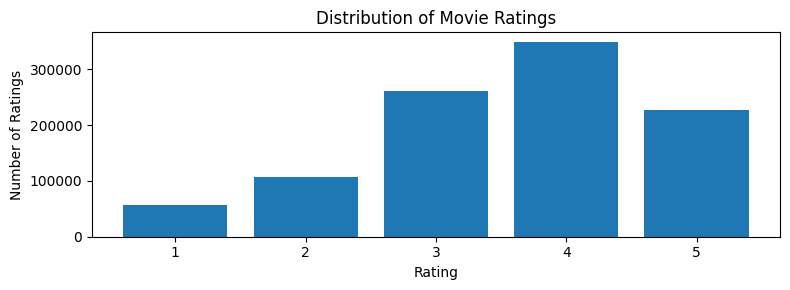

In [ ]:
import matplotlib.pyplot as plt

rating_counts = ratings["rating"].value_counts().sort_index()

plt.figure(figsize=(8, 3))

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.tight_layout()
plt.savefig(
    "rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**ii.Most-Rated Movies**

..Count rating

In [ ]:
movie_rating_counts = (
    ratings.groupby("movieId")
    .size()
    .reset_index(name="rating_count")
)

In [ ]:
most_rated_movies = movie_rating_counts.merge(
    movies[["movieId", "title"]],
    on="movieId",
    how="left"
)

In [ ]:
most_rated_movies = most_rated_movies.sort_values(
    "rating_count",
    ascending=False
)

..Display top 10

In [ ]:
top_10_most_rated = most_rated_movies.head(10)

display(top_10_most_rated)

,movieId,rating_count,title
2651,2858,3428,American Beauty (1999)
253,260,2991,Star Wars: Episode IV - A New Hope (1977)
1106,1196,2990,Star Wars: Episode V - The Empire Strikes Back...
1120,1210,2883,Star Wars: Episode VI - Return of the Jedi (1983)
466,480,2672,Jurassic Park (1993)
1848,2028,2653,Saving Private Ryan (1998)
575,589,2649,Terminator 2: Judgment Day (1991)
2374,2571,2590,"Matrix, The (1999)"
1178,1270,2583,Back to the Future (1985)
579,593,2578,"Silence of the Lambs, The (1991)"


**..Visualize Top 10 Most-Rated Movies**

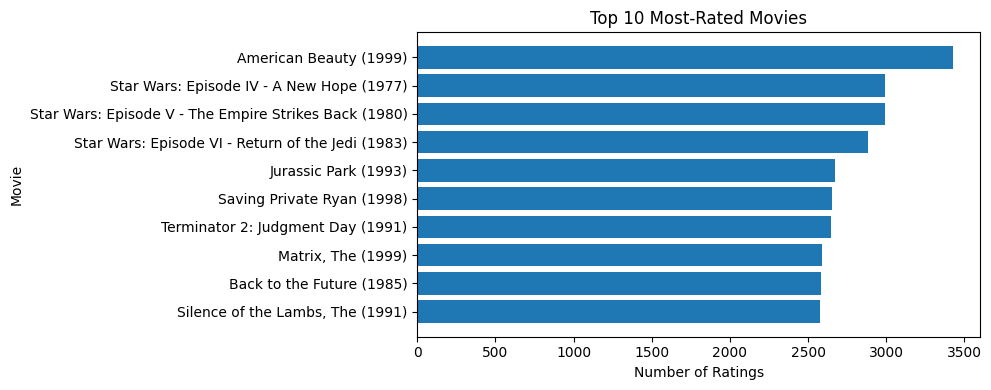

In [ ]:
plt.figure(figsize=(10, 4))

plt.barh(
    top_10_most_rated["title"][::-1],
    top_10_most_rated["rating_count"][::-1]
)

plt.title("Top 10 Most-Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")

plt.tight_layout()

plt.savefig(
    "top_10_most_rated_movies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

..Average Rating by Movie

In [ ]:
movie_avg_ratings = (
    ratings.groupby("movieId")["rating"]
    .agg(["mean", "count"])
    .reset_index()
)

movie_avg_ratings.columns = [
    "movieId",
    "average_rating",
    "rating_count"
]

In [ ]:
movie_avg_ratings = movie_avg_ratings.merge(
    movies[["movieId", "title"]],
    on="movieId",
    how="left"
)

In [ ]:
popular_movies = movie_avg_ratings[
    movie_avg_ratings["rating_count"] >= 100
]

..High rated movies

In [ ]:
top_10_highest_rated = (
    popular_movies
    .sort_values("average_rating", ascending=False)
    .head(10)
)

display(
    top_10_highest_rated[
        ["title", "average_rating", "rating_count"]
    ]
)

,title,average_rating,rating_count
1839,Seven Samurai (The Magnificent Seven) (Shichin...,4.560510,628
309,"Shawshank Redemption, The (1994)",4.554558,2227
802,"Godfather, The (1972)",4.524966,2223
708,"Close Shave, A (1995)",4.520548,657
49,"Usual Suspects, The (1995)",4.517106,1783
513,Schindler's List (1993),4.510417,2304
1066,"Wrong Trousers, The (1993)",4.507937,882
861,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.491489,470
1108,Raiders of the Lost Ark (1981),4.477725,2514
843,Rear Window (1954),4.476190,1050


**iii.Ratings Per User**

In [ ]:
ratings_per_user = (
    ratings.groupby("userId")
    .size()
)

In [ ]:
ratings_per_user.describe()

,0
count,6040.000000
mean,165.597517
std,192.747029
min,20.000000
25%,44.000000
50%,96.000000
75%,208.000000
max,2314.000000


..Visualze Ratings per user

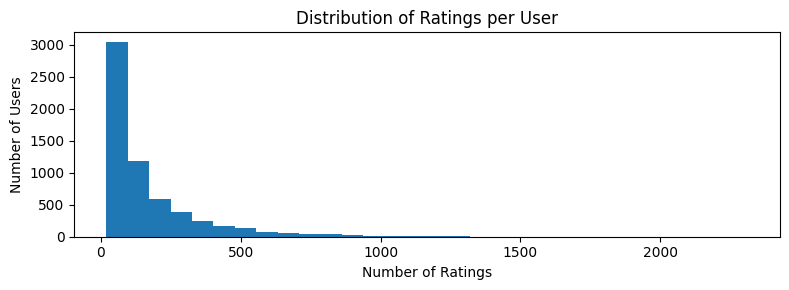

In [ ]:
plt.figure(figsize=(8, 3))

plt.hist(
    ratings_per_user,
    bins=30
)

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.tight_layout()

plt.savefig(
    "ratings_per_user.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**iv.Ratings Per Movie**

In [ ]:
ratings_per_movie = (
    ratings.groupby("movieId")
    .size()
)

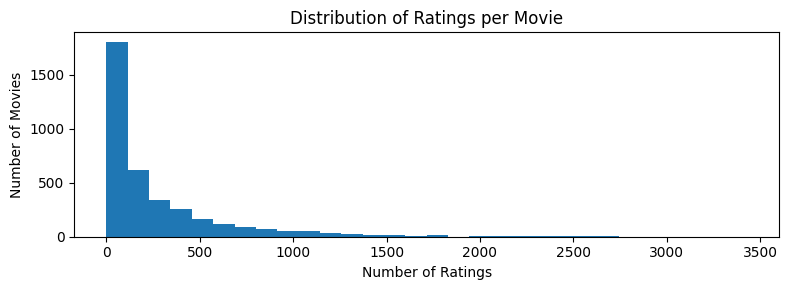

In [ ]:
plt.figure(figsize=(8, 3))

plt.hist(
    ratings_per_movie,
    bins=30
)

plt.title("Distribution of Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")

plt.tight_layout()

plt.savefig(
    "ratings_per_movie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**v.Analyze Genres**

In [ ]:
genre_counts = (
    movies["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

In [ ]:
print(genre_counts)

genres
Drama          1603
Comedy         1200
Action          503
Thriller        492
Romance         471
Horror          343
Adventure       283
Sci-Fi          276
Children's      251
Crime           211
War             143
Documentary     127
Musical         114
Mystery         106
Animation       105
Fantasy          68
Western          68
Film-Noir        44
Name: count, dtype: int64


..Top 10 Genre

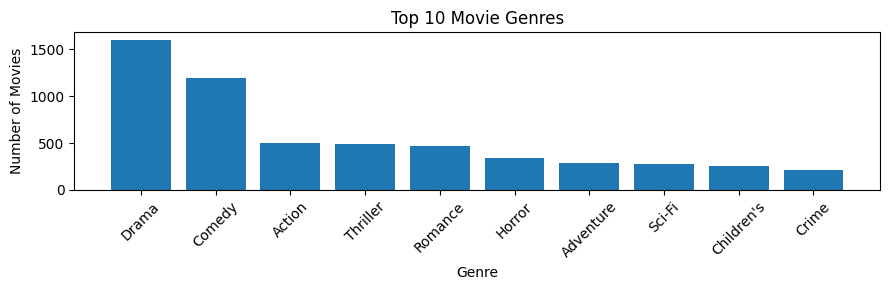

In [ ]:
top_genres = genre_counts.head(10)

plt.figure(figsize=(9, 3))

plt.bar(
    top_genres.index,
    top_genres.values
)

plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "top_10_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**vi.Check Dataset Sparsity**

In [ ]:
total_possible_interactions = (
    num_users * num_movies
)

actual_interactions = len(ratings)

sparsity = (
    1 - actual_interactions / total_possible_interactions
) * 100

print(
    f"Dataset Sparsity: {sparsity:.2f}%"
)

Dataset Sparsity: 95.53%


## Exploratory Data Analysis Summary

The MovieLens 1M dataset contains thousands of users and movies with
over one million recorded ratings. The rating distribution shows that
users tend to provide ratings toward the higher end of the 1–5 scale.

The analysis also shows that some movies receive substantially more
ratings than others, indicating differences in movie popularity.
Similarly, users vary considerably in the number of movies they rate.

The user-item interaction matrix is highly sparse because each user
has rated only a small portion of all available movies. This sparsity
makes matrix factorization an appropriate approach for discovering
latent user and movie preferences and generating personalized
recommendations.



---



# 4.Prepare User-Item Interaction Data

In [ ]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [ ]:
print(ratings.shape)
print(ratings[["userId", "movieId", "rating"]].head())

(1000209, 4)
   userId  movieId  rating
0       1     1193       5
1       1      661       3
2       1      914       3
3       1     3408       4
4       1     2355       5


..Create the User-Item Matrix

In [ ]:
user_item_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

In [ ]:
user_item_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Users:", user_item_matrix.shape[0])
print("Movies:", user_item_matrix.shape[1])
print("Matrix Shape:", user_item_matrix.shape)

Users: 6040
Movies: 3706
Matrix Shape: (6040, 3706)


..Calculate Total Possible Interactions

In [ ]:
total_possible = (
    user_item_matrix.shape[0] *
    user_item_matrix.shape[1]
)

print("Total Possible Interactions:", total_possible)

Total Possible Interactions: 22384240


.. Calculate Actual Interactions

In [ ]:
actual_interactions = user_item_matrix.count().sum()

print("Actual Interactions:", actual_interactions)

Actual Interactions: 1000209


.. Calculate Sparsity

In [ ]:
sparsity = (
    1 - actual_interactions / total_possible
) * 100

print(f"Matrix Sparsity: {sparsity:.2f}%")

Matrix Sparsity: 95.53%


.. Check How Many Movies Each User Rated

In [ ]:
ratings_per_user = (
    ratings.groupby("userId")["movieId"]
    .count()
)

print(ratings_per_user.describe())

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
Name: movieId, dtype: float64


In [ ]:
print(
    ratings_per_user
    .sort_values(ascending=False)
    .head(10)
)

userId
4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
889     1518
3618    1344
2063    1323
1150    1302
1015    1286
Name: movieId, dtype: int64


.. Check How Many Users Rated Each Movie

In [ ]:
users_per_movie = (
    ratings.groupby("movieId")["userId"]
    .count()
)

print(users_per_movie.describe())

count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
Name: userId, dtype: float64


In [ ]:
print(
    users_per_movie
    .sort_values(ascending=False)
    .head(10)
)

movieId
2858    3428
260     2991
1196    2990
1210    2883
480     2672
2028    2653
589     2649
2571    2590
1270    2583
593     2578
Name: userId, dtype: int64


## User-Item Interaction Matrix

For the recommendation system, the cleaned ratings data was transformed
into a User-Item interaction matrix. Each row represents a user, each
column represents a movie, and each cell contains the rating provided by
that user for the corresponding movie.

Most cells in the matrix are empty because users have rated only a small
subset of all available movies. Therefore, the matrix is highly sparse.
This sparsity is an important characteristic of recommendation systems
and motivates the use of matrix factorization techniques such as SVD.

Missing values were not replaced with zero because an absent rating means
that the user has not interacted with the movie, rather than giving it a
rating of zero.


---



# 5 — Train/Test Split

In [ ]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 15.6 MB/s eta 0:00:00


.. Create Train/Test Data

In [ ]:
from surprise import Dataset, Reader
from surprise.model_selection import train_test_split

# Define rating scale
reader = Reader(rating_scale=(1, 5))

# Load ratings into Surprise format
data = Dataset.load_from_df(
    ratings[["userId", "movieId", "rating"]],
    reader
)

# Split into 80% training and 20% testing
trainset, testset = train_test_split(
    data,
    test_size=0.20,
    random_state=42
)

print("Training ratings:", trainset.n_ratings)
print("Testing ratings:", len(testset))

Training ratings: 800167
Testing ratings: 200042


## Train/Test Split

The cleaned MovieLens ratings dataset is divided into training and testing sets.

- 80% of the ratings are used for training.
- 20% of the ratings are reserved for testing.
- The training set is used to learn hidden user and movie preferences.
- The testing set is used to evaluate the recommendation model.
- A random state of 42 is used to ensure reproducibility.

The timestamp column is not used because the basic SVD model focuses on user-item ratings.


---



# 6- Train the SVD Matrix Factorization Model

In [ ]:
from surprise import SVD

**.. Create the SVD Model**

In [ ]:
svd_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

**.. Train the Model**

In [ ]:
svd_model.fit(trainset)

print("SVD model training completed successfully!")

SVD model training completed successfully!


**.. Make a Test Prediction**

In [ ]:
# Take one rating from the test set
user_id, movie_id, actual_rating = testset[0]

# Predict the rating
prediction = svd_model.predict(user_id, movie_id)

print("User ID:", user_id)
print("Movie ID:", movie_id)
print("Actual Rating:", actual_rating)
print("Predicted Rating:", round(prediction.est, 2))

User ID: 1841
Movie ID: 3717
Actual Rating: 1.0
Predicted Rating: 2.24


##  SVD Matrix Factorization

Singular Value Decomposition (SVD) is used to build the collaborative filtering recommendation model.

The model learns latent factors representing hidden relationships between users and movies. These factors allow the model to estimate how much a user may like a movie they have not rated.

The model is trained using the 80% training dataset.

The main parameters used are:

- `n_factors = 100`
- `n_epochs = 20`
- `lr_all = 0.005`
- `reg_all = 0.02`

After training, the model can predict a user's rating for a movie.



---



#7 — Hyperparameter Tuning

In [ ]:
from surprise import SVD
from surprise import accuracy

**.. Test Different SVD Parameters**

In [ ]:
results = []

factors_list = [50, 100, 150, 200]
epochs_list = [10, 20, 30]

for factors in factors_list:
    for epochs in epochs_list:

        model = SVD(
            n_factors=factors,
            n_epochs=epochs,
            lr_all=0.005,
            reg_all=0.02,
            random_state=42
        )

        # Train model
        model.fit(trainset)

        # Predict on test data
        predictions = model.test(testset)

        # Calculate RMSE
        rmse = accuracy.rmse(predictions, verbose=False)

        # Calculate MAE
        mae = accuracy.mae(predictions, verbose=False)

        results.append({
            "n_factors": factors,
            "n_epochs": epochs,
            "RMSE": rmse,
            "MAE": mae
        })

        print(
            f"Factors: {factors}, "
            f"Epochs: {epochs}, "
            f"RMSE: {rmse:.4f}, "
            f"MAE: {mae:.4f}"
        )

Factors: 50, Epochs: 10, RMSE: 0.8946, MAE: 0.7068
Factors: 50, Epochs: 20, RMSE: 0.8706, MAE: 0.6839
Factors: 50, Epochs: 30, RMSE: 0.8751, MAE: 0.6844
Factors: 100, Epochs: 10, RMSE: 0.8922, MAE: 0.7040
Factors: 100, Epochs: 20, RMSE: 0.8729, MAE: 0.6845
Factors: 100, Epochs: 30, RMSE: 0.8821, MAE: 0.6891
Factors: 150, Epochs: 10, RMSE: 0.8908, MAE: 0.7027
Factors: 150, Epochs: 20, RMSE: 0.8775, MAE: 0.6884
Factors: 150, Epochs: 30, RMSE: 0.8872, MAE: 0.6941
Factors: 200, Epochs: 10, RMSE: 0.8908, MAE: 0.7029
Factors: 200, Epochs: 20, RMSE: 0.8788, MAE: 0.6899
Factors: 200, Epochs: 30, RMSE: 0.8867, MAE: 0.6944


.. Compare the Results

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

results_df

,n_factors,n_epochs,RMSE,MAE
0,50,20,0.870608,0.683880
1,100,20,0.872893,0.684520
2,50,30,0.875145,0.684427
3,150,20,0.877498,0.688353
4,200,20,0.878814,0.689902
5,100,30,0.882148,0.689075
6,200,30,0.886702,0.694392
7,150,30,0.887207,0.694069
8,200,10,0.890776,0.702945
9,150,10,0.890806,0.702675


.. Find the Best Parameters

In [ ]:
best_result = results_df.iloc[0]

print("Best SVD Configuration")
print("----------------------")
print("Number of Factors:", int(best_result["n_factors"]))
print("Number of Epochs:", int(best_result["n_epochs"]))
print("RMSE:", round(best_result["RMSE"], 4))
print("MAE:", round(best_result["MAE"], 4))

Best SVD Configuration
----------------------
Number of Factors: 50
Number of Epochs: 20
RMSE: 0.8706
MAE: 0.6839


.. Save the Best Parameters

In [ ]:
best_factors = int(best_result["n_factors"])
best_epochs = int(best_result["n_epochs"])

print("Best Factors:", best_factors)
print("Best Epochs:", best_epochs)

Best Factors: 50
Best Epochs: 20


## Hyperparameter Tuning

Several SVD configurations were tested to find the best-performing collaborative filtering model.

The following hyperparameters were evaluated:

- Number of latent factors: 50, 100, 150, and 200
- Number of training epochs: 10, 20, and 30
- Learning rate: 0.005
- Regularization: 0.02

Each configuration was evaluated using RMSE and MAE on the test dataset.

Lower RMSE and MAE values indicate better prediction performance.

The configuration with the lowest RMSE was selected as the best SVD configuration.



---



# 8 — Final Model Evaluation

.. Train the Final SVD Model

In [ ]:
from surprise import SVD
from surprise import accuracy

# Best parameters from Step 7
best_factors = 50
best_epochs = 20

# Create final model
final_model = SVD(
    n_factors=best_factors,
    n_epochs=best_epochs,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

# Train final model
final_model.fit(trainset)

print("Final SVD model trained successfully!")

Final SVD model trained successfully!


.. Generate Predictions

In [ ]:
# Generate predictions for the entire test set
test_predictions = final_model.test(testset)

print("Total test predictions:", len(test_predictions))

Total test predictions: 200042


.. Calculate RMSE

In [ ]:
rmse = accuracy.rmse(test_predictions, verbose=False)

print("Final RMSE:", round(rmse, 4))

Final RMSE: 0.8706


.. Calculate MAE

In [ ]:
mae = accuracy.mae(test_predictions, verbose=False)

print("Final MAE:", round(mae, 4))

Final MAE: 0.6839


**..Visualize Actual vs Predicted Ratings**

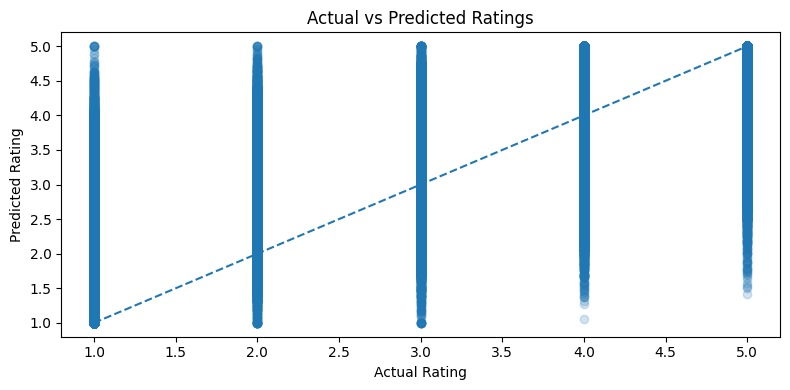

In [ ]:
import matplotlib.pyplot as plt

actual_ratings = [pred.r_ui for pred in test_predictions]
predicted_ratings = [pred.est for pred in test_predictions]

plt.figure(figsize=(8, 4))

plt.scatter(
    actual_ratings,
    predicted_ratings,
    alpha=0.2
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")

plt.plot(
    [1, 5],
    [1, 5],
    linestyle="--"
)

plt.tight_layout()
plt.savefig("actual_vs_predicted_ratings.png", dpi=300)
plt.show()

## Final Model Evaluation

The final SVD model was trained using the best hyperparameters identified during tuning:

- Number of factors: 50
- Number of epochs: 20
- Learning rate: 0.005
- Regularization: 0.02

The model was evaluated on the 20% test dataset using RMSE and MAE.

### Results

- RMSE: 0.8706
- MAE: 0.6839

RMSE measures the overall prediction error while giving more weight to larger errors. MAE represents the average absolute difference between the actual and predicted ratings.

The evaluation results show that the model can reasonably estimate user ratings and can therefore be used to generate personalized movie recommendations.



---



# 9 — Build the Top-5 Recommendation Function

.. Create the Recommendation Function

In [ ]:
def get_top_5_recommendations(user_id, model, ratings, movies):

    # Movies already rated by the user
    watched_movies = set(
        ratings[ratings["userId"] == user_id]["movieId"]
    )

    # All available movies
    all_movies = set(movies["movieId"])

    # Movies the user has not rated
    unseen_movies = all_movies - watched_movies

    # Predict ratings for unseen movies
    predictions = []

    for movie_id in unseen_movies:
        prediction = model.predict(user_id, movie_id)

        predictions.append({
            "movieId": movie_id,
            "predicted_rating": prediction.est
        })

    # Convert predictions to DataFrame
    recommendations = pd.DataFrame(predictions)

    # Sort by predicted rating
    recommendations = recommendations.sort_values(
        by="predicted_rating",
        ascending=False
    )

    # Select Top 5
    top_5 = recommendations.head(5)

    # Add movie titles
    top_5 = top_5.merge(
        movies[["movieId", "title", "genres"]],
        on="movieId",
        how="left"
    )

    # Rearrange columns
    top_5 = top_5[
        ["movieId", "title", "genres", "predicted_rating"]
    ]

    return top_5.reset_index(drop=True)

.. Test the Function

In [ ]:
user_id = 1841

recommendations = get_top_5_recommendations(
    user_id,
    final_model,
    ratings,
    movies
)

recommendations

,movieId,title,genres,predicted_rating
0,912,Casablanca (1942),Drama|Romance|War,4.644162
1,3435,Double Indemnity (1944),Crime|Film-Noir,4.460175
2,858,"Godfather, The (1972)",Action|Crime|Drama,4.389955
3,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Film-Noir,4.350945
4,904,Rear Window (1954),Mystery|Thriller,4.346411


.. Make the Output Cleaner

In [ ]:
recommendations["predicted_rating"] = recommendations[
    "predicted_rating"
].round(2)

recommendations

,movieId,title,genres,predicted_rating
0,912,Casablanca (1942),Drama|Romance|War,4.64
1,3435,Double Indemnity (1944),Crime|Film-Noir,4.46
2,858,"Godfather, The (1972)",Action|Crime|Drama,4.39
3,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Film-Noir,4.35
4,904,Rear Window (1954),Mystery|Thriller,4.35


.. Check the User's Existing Ratings

In [ ]:
user_1841_ratings = ratings[
    ratings["userId"] == 1841
].merge(
    movies[["movieId", "title"]],
    on="movieId",
    how="left"
)

user_1841_ratings[
    ["movieId", "title", "rating"]
].head(10)

,movieId,title,rating
0,2053,"Honey, I Blew Up the Kid (1992)",1
1,3793,X-Men (2000),2
2,2997,Being John Malkovich (1999),5
3,1258,"Shining, The (1980)",4
4,585,"Brady Bunch Movie, The (1995)",1
5,586,Home Alone (1990),3
6,588,Aladdin (1992),5
7,589,Terminator 2: Judgment Day (1991),4
8,1,Toy Story (1995),5
9,2,Jumanji (1995),3


.. Verify No Previously Rated Movies Are Recommended

In [ ]:
recommended_movie_ids = set(
    recommendations["movieId"]
)

watched_movie_ids = set(
    ratings[ratings["userId"] == user_id]["movieId"]
)

overlap = recommended_movie_ids.intersection(
    watched_movie_ids
)

print("Recommended movies already rated:", len(overlap))

Recommended movies already rated: 0


.. Test Another User

In [ ]:
user_id = 1

recommendations_user_1 = get_top_5_recommendations(
    user_id,
    final_model,
    ratings,
    movies
)

recommendations_user_1["predicted_rating"] = (
    recommendations_user_1["predicted_rating"].round(2)
)

recommendations_user_1

,movieId,title,genres,predicted_rating
0,318,"Shawshank Redemption, The (1994)",Drama,5.00
1,593,"Silence of the Lambs, The (1991)",Drama|Thriller,4.91
2,2905,Sanjuro (1962),Action|Adventure,4.90
3,2019,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama,4.88
4,1212,"Third Man, The (1949)",Mystery|Thriller,4.87


## Top-5 Movie Recommendation Function

A recommendation function was created using the trained SVD model.

The function accepts a User ID and performs the following steps:

1. Identifies movies already rated by the user.
2. Finds movies that the user has not rated.
3. Uses the trained SVD model to predict ratings for unseen movies.
4. Sorts the movies according to their predicted ratings.
5. Returns the five movies with the highest predicted ratings.

Previously rated movies are excluded from the recommendations so that the system recommends new movies to the user.

The final output contains the movie ID, title, genres, and predicted rating.



---



# 10 — Test the Recommendation Engine on 3 Users

.. Select 3 Users

In [ ]:
# Select 3 users for testing
test_users = [1, 1841, 5000]

print("Test Users:", test_users)

Test Users: [1, 1841, 5000]


.. Generate Top-5 Recommendations

In [ ]:
# Generate recommendations for the 3 users

all_recommendations = {}

for user_id in test_users:

    recommendations = get_top_5_recommendations(
        user_id,
        final_model,
        ratings,
        movies
    )

    recommendations["predicted_rating"] = (
        recommendations["predicted_rating"].round(2)
    )

    all_recommendations[user_id] = recommendations

    print(f"\n{'=' * 60}")
    print(f"Top 5 Recommendations for User {user_id}")
    print(f"{'=' * 60}")

    display(recommendations)


Top 5 Recommendations for User 1


,movieId,title,genres,predicted_rating
0,318,"Shawshank Redemption, The (1994)",Drama,5.00
1,593,"Silence of the Lambs, The (1991)",Drama|Thriller,4.91
2,2905,Sanjuro (1962),Action|Adventure,4.90
3,2019,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama,4.88
4,1212,"Third Man, The (1949)",Mystery|Thriller,4.87



Top 5 Recommendations for User 1841


,movieId,title,genres,predicted_rating
0,912,Casablanca (1942),Drama|Romance|War,4.64
1,3435,Double Indemnity (1944),Crime|Film-Noir,4.46
2,858,"Godfather, The (1972)",Action|Crime|Drama,4.39
3,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Film-Noir,4.35
4,904,Rear Window (1954),Mystery|Thriller,4.35



Top 5 Recommendations for User 5000


,movieId,title,genres,predicted_rating
0,34,Babe (1995),Children's|Comedy|Drama,5.0
1,3801,Anatomy of a Murder (1959),Drama|Mystery,5.0
2,1,Toy Story (1995),Animation|Children's|Comedy,5.0
3,904,Rear Window (1954),Mystery|Thriller,5.0
4,1945,On the Waterfront (1954),Crime|Drama,5.0


.. Display Only Movie Title and Predicted Rating

In [ ]:
for user_id in test_users:

    print(f"\nTop 5 Recommendations for User {user_id}")

    display(
        all_recommendations[user_id][
            ["title", "genres", "predicted_rating"]
        ]
    )


Top 5 Recommendations for User 1


,title,genres,predicted_rating
0,"Shawshank Redemption, The (1994)",Drama,5.00
1,"Silence of the Lambs, The (1991)",Drama|Thriller,4.91
2,Sanjuro (1962),Action|Adventure,4.90
3,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama,4.88
4,"Third Man, The (1949)",Mystery|Thriller,4.87



Top 5 Recommendations for User 1841


,title,genres,predicted_rating
0,Casablanca (1942),Drama|Romance|War,4.64
1,Double Indemnity (1944),Crime|Film-Noir,4.46
2,"Godfather, The (1972)",Action|Crime|Drama,4.39
3,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Film-Noir,4.35
4,Rear Window (1954),Mystery|Thriller,4.35



Top 5 Recommendations for User 5000


,title,genres,predicted_rating
0,Babe (1995),Children's|Comedy|Drama,5.0
1,Anatomy of a Murder (1959),Drama|Mystery,5.0
2,Toy Story (1995),Animation|Children's|Comedy,5.0
3,Rear Window (1954),Mystery|Thriller,5.0
4,On the Waterfront (1954),Crime|Drama,5.0


.. Verify the Recommendations

In [ ]:
for user_id in test_users:

    recommended_ids = set(
        all_recommendations[user_id]["movieId"]
    )

    rated_ids = set(
        ratings[ratings["userId"] == user_id]["movieId"]
    )

    overlap = recommended_ids.intersection(rated_ids)

    print(
        f"User {user_id} - "
        f"Already rated recommendations: {len(overlap)}"
    )

User 1 - Already rated recommendations: 0
User 1841 - Already rated recommendations: 0
User 5000 - Already rated recommendations: 0


.. Create One Combined Table

In [ ]:
combined_recommendations = []

for user_id in test_users:

    user_recommendations = all_recommendations[user_id].copy()
    user_recommendations["userId"] = user_id

    combined_recommendations.append(user_recommendations)

combined_recommendations = pd.concat(
    combined_recommendations,
    ignore_index=True
)

combined_recommendations = combined_recommendations[
    [
        "userId",
        "movieId",
        "title",
        "genres",
        "predicted_rating"
    ]
]

combined_recommendations

,userId,movieId,title,genres,predicted_rating
0,1,318,"Shawshank Redemption, The (1994)",Drama,5.00
1,1,593,"Silence of the Lambs, The (1991)",Drama|Thriller,4.91
2,1,2905,Sanjuro (1962),Action|Adventure,4.90
3,1,2019,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama,4.88
4,1,1212,"Third Man, The (1949)",Mystery|Thriller,4.87
5,1841,912,Casablanca (1942),Drama|Romance|War,4.64
6,1841,3435,Double Indemnity (1944),Crime|Film-Noir,4.46
7,1841,858,"Godfather, The (1972)",Action|Crime|Drama,4.39
8,1841,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Film-Noir,4.35
9,1841,904,Rear Window (1954),Mystery|Thriller,4.35


.. Save the Results

In [ ]:
combined_recommendations.to_csv(
    "sample_recommendations.csv",
    index=False
)

print("Sample recommendations saved successfully!")

Sample recommendations saved successfully!


.. Save the Recommendation Results

In [ ]:
combined_recommendations.to_csv(
    "sample_recommendations.csv",
    index=False
)

print("Sample recommendations saved successfully!")

Sample recommendations saved successfully!


## Testing the Recommendation Engine

The recommendation engine was tested using three different MovieLens users.

For each user, the system:

1. Identified movies that the user had not previously rated.
2. Predicted ratings for the unseen movies using the trained SVD model.
3. Ranked the movies according to their predicted ratings.
4. Returned the five movies with the highest predicted ratings.

A total of 15 recommendations were generated for the three test users.

Previously rated movies were also checked to ensure that they were not included in the recommendations.


---



# 11 — Save the Trained SVD Model

In [ ]:
import joblib

In [ ]:
joblib.dump(
    final_model,
    "svd_recommendation_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_model = joblib.load(
    "svd_recommendation_model.pkl"
)

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [ ]:
user_id = 1841

loaded_recommendations = get_top_5_recommendations(
    user_id,
    loaded_model,
    ratings,
    movies
)

loaded_recommendations["predicted_rating"] = (
    loaded_recommendations["predicted_rating"].round(2)
)

loaded_recommendations

,movieId,title,genres,predicted_rating
0,912,Casablanca (1942),Drama|Romance|War,4.64
1,3435,Double Indemnity (1944),Crime|Film-Noir,4.46
2,858,"Godfather, The (1972)",Action|Crime|Drama,4.39
3,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Film-Noir,4.35
4,904,Rear Window (1954),Mystery|Thriller,4.35


##  Save the Trained Model

The final SVD recommendation model was saved as a Pickle file using Joblib.

Saving the trained model allows the recommendation system to be reused without retraining the model every time.

The saved model was also loaded again and tested to verify that it can generate Top-5 movie recommendations successfully.

Model file:

`svd_recommendation_model.pkl`



---



 # 12 — Sample Prediction Script


.. Create recommendation.py

In [ ]:
import pandas as pd
import joblib

# Load model
model = joblib.load("svd_recommendation_model.pkl")

# Load datasets
ratings = pd.read_csv("ratings_cleaned.csv")
movies = pd.read_csv("movies_cleaned.csv")


def get_top_5_recommendations(user_id):

    # Movies already rated by the user
    watched_movies = set(
        ratings[ratings["userId"] == user_id]["movieId"]
    )

    # All movies
    all_movies = set(movies["movieId"])

    # Movies not rated by the user
    unseen_movies = all_movies - watched_movies

    predictions = []

    # Predict ratings for unseen movies
    for movie_id in unseen_movies:

        prediction = model.predict(user_id, movie_id)

        predictions.append({
            "movieId": movie_id,
            "predicted_rating": prediction.est
        })

    # Convert predictions to DataFrame
    recommendations = pd.DataFrame(predictions)

    # Sort by predicted rating
    recommendations = recommendations.sort_values(
        by="predicted_rating",
        ascending=False
    )

    # Select Top 5
    top_5 = recommendations.head(5)

    # Add movie details
    top_5 = top_5.merge(
        movies[["movieId", "title", "genres"]],
        on="movieId",
        how="left"
    )

    # Round predicted ratings
    top_5["predicted_rating"] = (
        top_5["predicted_rating"].round(2)
    )

    return top_5[
        ["movieId", "title", "genres", "predicted_rating"]
    ].reset_index(drop=True)


# Test 3 users
test_users = [1, 1841, 5000]

for user_id in test_users:

    print("\n" + "=" * 70)
    print(f"Top 5 Recommendations for User {user_id}")
    print("=" * 70)

    recommendations = get_top_5_recommendations(user_id)

    print(recommendations.to_string(index=False))


Top 5 Recommendations for User 1
 movieId                                                               title           genres  predicted_rating
     318                                    Shawshank Redemption, The (1994)            Drama              5.00
     593                                    Silence of the Lambs, The (1991)   Drama|Thriller              4.91
    2905                                                      Sanjuro (1962) Action|Adventure              4.90
    2019 Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)     Action|Drama              4.88
    1212                                               Third Man, The (1949) Mystery|Thriller              4.87

Top 5 Recommendations for User 1841
 movieId                                         title             genres  predicted_rating
     912                             Casablanca (1942)  Drama|Romance|War              4.64
    3435                       Double Indemnity (1944)    Crime|Film-Noir

# 🎬 Echo Recommendation Engine

A collaborative filtering movie recommendation system built using **SVD (Singular Value Decomposition)** and the **MovieLens 1M dataset**.

The system learns user preferences from historical movie ratings and recommends the **Top 5 movies** that a user is most likely to enjoy.

---

## 📌 Project Overview

The Echo Recommendation Engine is a personalized movie recommendation system based on collaborative filtering.

Instead of recommending movies only based on their genres or content, the system learns from the behavior of users who have rated movies.

The system:

* Processes MovieLens user-movie rating data
* Performs exploratory data analysis
* Creates a user-item interaction matrix
* Uses SVD matrix factorization for collaborative filtering
* Tunes SVD hyperparameters
* Evaluates the model using RMSE and MAE
* Predicts ratings for movies a user has not rated
* Generates the Top 5 movie recommendations
* Saves the trained model for future use

---

## 🎯 Objectives

The main objectives of this project are:

1. Build a collaborative filtering recommendation system.
2. Apply matrix factorization using SVD.
3. Predict user ratings for unseen movies.
4. Evaluate recommendation performance using RMSE and MAE.
5. Generate personalized Top 5 movie recommendations.
6. Demonstrate recommendations for multiple users.

---

## 📊 Dataset

This project uses the **MovieLens 1M dataset**.

The dataset contains:

* Approximately 1 million movie ratings
* 6,040 users
* Approximately 3,700 movies
* Ratings ranging from 1 to 5

### Dataset Files

| File          | Description                  |
| ------------- | ---------------------------- |
| `ratings.dat` | User movie ratings           |
| `movies.dat`  | Movie titles and genres      |
| `users.dat`   | User demographic information |

For the recommendation model, the main files used are:

* `ratings.dat`
* `movies.dat`

The `users.dat` file is not required for the basic SVD recommendation model.

---

## 🧠 Recommendation Approach

This project uses **Collaborative Filtering**.

Collaborative filtering recommends items based on the preferences and behavior of users.

For example, if two users have similar movie-rating patterns, movies liked by one user can be recommended to the other user.

### Matrix Factorization

The user-item rating matrix is factorized into lower-dimensional latent factors.

SVD learns hidden relationships between:

* Users
* Movies
* Ratings

These latent factors allow the system to estimate how much a user may like a movie they have not previously rated.

---

## 🔄 System Workflow

```text
MovieLens Dataset
       ↓
Data Cleaning
       ↓
Movie Data Cleaning
       ↓
Exploratory Data Analysis
       ↓
User-Item Interaction Matrix
       ↓
Train/Test Split
       ↓
SVD Matrix Factorization
       ↓
Hyperparameter Tuning
       ↓
RMSE & MAE Evaluation
       ↓
Predict Unseen Movies
       ↓
Sort Predicted Ratings
       ↓
Top 5 Movie Recommendations
```

---

## 🧹 Data Preprocessing

The ratings dataset was cleaned by:

* Removing missing values
* Removing duplicate records
* Removing invalid user IDs
* Removing invalid movie IDs
* Removing ratings outside the 1–5 range

Movie data was cleaned by:

* Removing missing movie IDs
* Removing movies without titles
* Handling missing genres
* Removing duplicate movies
* Cleaning movie titles and genre values

---

## 📈 Exploratory Data Analysis

Several visualizations were created during the analysis, including:

* Rating distribution
* Top 10 most-rated movies
* Top movies by average rating
* Ratings per user
* Ratings per movie
* Top movie genres
* Dataset sparsity
* Actual vs predicted ratings

---

## 🤖 Model

The recommendation model uses **SVD from the Surprise library**.

### Final Model Parameters

| Parameter         | Value |
| ----------------- | ----: |
| Number of factors |    50 |
| Number of epochs  |    20 |
| Learning rate     | 0.005 |
| Regularization    |  0.02 |
| Random state      |    42 |

---

## 🔍 Hyperparameter Tuning

Several SVD configurations were tested.

The tested values included:

### Number of Factors

```text
50
100
150
200
```

### Number of Epochs

```text
10
20
30
```

The best configuration was selected based on the lowest RMSE.

### Best Configuration

```text
n_factors = 50
n_epochs = 20
```

---

## 📊 Model Evaluation

The final model was evaluated on 20% of the ratings reserved for testing.

### Results

| Metric |      Score |
| ------ | ---------: |
| RMSE   | **0.8706** |
| MAE    | **0.6839** |

### RMSE

Root Mean Squared Error measures the difference between actual and predicted ratings, giving more importance to larger errors.

### MAE

Mean Absolute Error represents the average absolute difference between the actual and predicted ratings.

Lower values indicate better prediction performance.

---

## 🎬 Recommendation System

The recommendation function takes a **User ID** and:

1. Finds movies already rated by the user.
2. Removes those movies from the candidate list.
3. Predicts ratings for unseen movies.
4. Sorts movies by predicted rating.
5. Returns the Top 5 movies.

### Example

```python
recommendations = get_top_5_recommendations(
    user_id=1841,
    model=final_model,
    ratings=ratings,
    movies=movies
)

print(recommendations)
```

The output contains:

```text
movieId
title
genres
predicted_rating
```

---

## 👥 Sample Users

The recommendation engine was tested with three users:

```text
User 1
User 1841
User 5000
```

For each user, the system generates five personalized movie recommendations.

Therefore:

```text
3 Users × 5 Recommendations = 15 Recommendations
```

---

## 📁 Project Structure

```text
Echo-Recommendation-Engine/
│
├── Echo_Recommendation_Engine.ipynb
├── recommendation.py
├── svd_recommendation_model.pkl
├── ratings_cleaned.csv
├── movies_cleaned.csv
├── sample_recommendations.csv
├── actual_vs_predicted_ratings.png
├── rating_distribution.png
├── top_10_most_rated_movies.png
├── ratings_per_user.png
├── ratings_per_movie.png
├── top_10_genres.png
├── requirements.txt
└── README.md
```

---

## 🛠️ Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Scikit-Surprise
* Joblib
* Jupyter Notebook / Google Colab
* Git
* GitHub

---

## 📦 Installation

Clone the repository:

```bash
git clone https://github.com/YOUR_USERNAME/Echo-Recommendation-Engine.git
```

Move into the project directory:

```bash
cd Echo-Recommendation-Engine
```

Install the required packages:

```bash
pip install -r requirements.txt
```

---

## ▶️ Running the Recommendation Script

After installing the required packages, run:

```bash
python recommendation.py
```

The script loads the saved SVD model and generates Top 5 recommendations for the three sample users.

---

## 💾 Saved Model

The trained model is saved as:

```text
svd_recommendation_model.pkl
```

The saved model allows recommendations to be generated without retraining the SVD model every time.

---

## 📓 Jupyter Notebook

The complete machine learning workflow is available in:

```text
Echo_Recommendation_Engine.ipynb
```

The notebook contains:

* Data cleaning
* EDA
* User-item matrix
* Train/test split
* SVD training
* Hyperparameter tuning
* Model evaluation
* Recommendation generation
* Testing with three users

---

## 🚀 Future Improvements

Possible future improvements include:

* Adding a Streamlit web interface
* Adding user login and profiles
* Supporting real-time recommendations
* Using implicit feedback such as watch history
* Combining collaborative filtering with content-based filtering
* Adding movie posters
* Using additional user demographic information
* Trying ALS or other matrix factorization methods
* Improving recommendation diversity

---

## 👨‍💻 Author

**Your Name**

Computer Science Student

---

## 📄 License

This project is created for educational and academic purposes.
